In [1]:
import pandas as pd

# Load the dataset
data = pd.read_excel("data_filtered.xlsx", sheet_name="full_data")

# Remove non-comparable territories / aggregate categories
excluded_countries = [
    "St Barthelemy",
    "St Martin (French part)",
    "Reunion",
    "Martinique",
    "Guadeloupe",
    "Aland Islands",
    "Cyprus (Not otherwise specified)",
    "French West Indies (Not In Use)",
    "Canary Islands",
    "French Guiana"
]

data = data[~data["Domicile_named_country"].isin(excluded_countries)].copy()

# Define treated and synthetic control country groups
eu_real = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus (European Union)",
    "Czech Republic", "Denmark", "Estonia", "Finland", "France",
    "Germany", "Greece", "Hungary", "Italy",
    "Latvia", "Lithuania", "Luxembourg", "Malta", "Netherlands",
    "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden"
]

eu_synth = [
    "Australia", "Saudi Arabia", "Russian Federation", "Peru", "Kuwait",
    "Bahrain", "Singapore", "Switzerland", "Hong Kong",
    "United States of America", "Thailand", "Canada", "Mauritius",
    "Qatar", "Norway", "Israel", "Malaysia", "Jordan", "Albania",
    "Serbia", "Ireland", "Jersey", "Macao", "United Arab Emirates",
    "Vietnam [Viet Nam]", "Turkey"
]

# Keep only observations in the treated or synthetic groups
data = data[data["Domicile_named_country"].isin(eu_real + eu_synth)].copy()

# Create indicator variables and group label
data["real_EU"] = data["Domicile_named_country"].isin(eu_real).astype(int)
data["synth_EU"] = data["Domicile_named_country"].isin(eu_synth).astype(int)

data["EU_group"] = "Other"
data.loc[data["Domicile_named_country"].isin(eu_real), "EU_group"] = "Real_EU"
data.loc[data["Domicile_named_country"].isin(eu_synth), "EU_group"] = "Synthetic_EU"

# Basic checks
print(data["Domicile_named_country"].unique())
print(data["EU_group"].value_counts())
print(data.head())


['Austria' 'Belgium' 'Bulgaria' 'Denmark' 'Finland' 'France' 'Germany'
 'Greece' 'Hungary' 'Ireland' 'Italy' 'Luxembourg' 'Malta' 'Netherlands'
 'Poland' 'Portugal' 'Romania' 'Spain' 'Sweden' 'Estonia' 'Latvia'
 'Lithuania' 'Croatia' 'Slovenia' 'Czech Republic' 'Slovakia'
 'Cyprus (European Union)' 'Jersey' 'Russian Federation' 'Mauritius'
 'Norway' 'Peru' 'Qatar' 'Saudi Arabia' 'Singapore' 'Switzerland'
 'Thailand' 'United Arab Emirates' 'Turkey' 'United States of America'
 'Vietnam [Viet Nam]' 'Serbia' 'Albania' 'Australia' 'Bahrain' 'Canada'
 'Hong Kong' 'Israel' 'Jordan' 'Kuwait' 'Macao' 'Malaysia']
EU_group
Real_EU         260
Synthetic_EU    260
Name: count, dtype: int64
    Year Domicile_named_country  Applicants  Accepted_applicants  \
40  2016                Austria         650                  370   
41  2017                Austria         590                  340   
42  2018                Austria         625                  335   
43  2019                Austria         62

In [2]:
import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

# ----------------------------
# Sanity check
# ----------------------------
data["EU_group"] = None
data.loc[data["Domicile_named_country"].isin(eu_real), "EU_group"] = "Real_EU"
data.loc[data["Domicile_named_country"].isin(eu_synth), "EU_group"] = "Synthetic_EU"

print(data["EU_group"].value_counts(dropna=False))

# 260/10 = 26 real European countries
# (excluding Ireland because it did not face the same restrictions,
# and excluding UK for obvious reasons)
# 260/10 = 26 synthetic countries
# (including Ireland as the most plausible counterfactual)

# ----------------------------
# pdata.frame equivalent
# ----------------------------
pdata_UCAS = data.set_index(["Domicile_named_country", "Year"]).sort_index()

# ----------------------------
# Clean data
# ----------------------------
df = pdata_UCAS.reset_index().copy()
df["Domicile_named_country"] = df["Domicile_named_country"].astype(str)
df["Year"] = df["Year"].astype(int)

# ----------------------------
# Treatment definition
# ----------------------------
df["Post"] = (df["Year"] >= 2021).astype(int)
df["Treated"] = df["Domicile_named_country"].isin(eu_real).astype(int)

# ----------------------------
# Pooled control category
# ----------------------------
df["treated_factor"] = np.where(
    df["Treated"] == 1,
    df["Domicile_named_country"],
    "CONTROL"
)

# ----------------------------
# Saturated interaction terms
# ----------------------------
treated_dummies = pd.get_dummies(df["treated_factor"], prefix="tf", dtype=float)
interaction_terms = treated_dummies.mul(df["Post"], axis=0)

control_col = "tf_CONTROL"
if control_col in interaction_terms.columns:
    interaction_terms = interaction_terms.drop(columns=[control_col])

print(interaction_terms.columns.tolist())

# ----------------------------
# Panel setup
# ----------------------------
df_panel = df.set_index(["Domicile_named_country", "Year"]).sort_index()
interaction_terms.index = df_panel.index

# Dependent variable
y = np.log(df_panel["Applicants"])

# ----------------------------
# Model 1: country + year FE
# ----------------------------
X1 = interaction_terms.copy()

m_sat_DK = PanelOLS(
    dependent=y,
    exog=X1,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_sat_DK = m_sat_DK.fit(cov_type="driscoll-kraay")
print(res_sat_DK.summary)

# ----------------------------
# Model 2: country FE only
# ----------------------------
X2 = interaction_terms.copy()

m_sat_DK1 = PanelOLS(
    dependent=y,
    exog=X2,
    entity_effects=True,
    time_effects=False,
    drop_absorbed=True
)

res_sat_DK1 = m_sat_DK1.fit(cov_type="driscoll-kraay")
print(res_sat_DK1.summary)

# ----------------------------
# Model 3: no FE
# ----------------------------
X3 = interaction_terms.copy()

m_sat_DK2 = PanelOLS(
    dependent=y,
    exog=X3,
    entity_effects=False,
    time_effects=False,
    drop_absorbed=True
)

res_sat_DK2 = m_sat_DK2.fit(cov_type="driscoll-kraay")
print(res_sat_DK2.summary)


EU_group
Real_EU         260
Synthetic_EU    260
Name: count, dtype: int64
['tf_Austria', 'tf_Belgium', 'tf_Bulgaria', 'tf_Croatia', 'tf_Cyprus (European Union)', 'tf_Czech Republic', 'tf_Denmark', 'tf_Estonia', 'tf_Finland', 'tf_France', 'tf_Germany', 'tf_Greece', 'tf_Hungary', 'tf_Italy', 'tf_Latvia', 'tf_Lithuania', 'tf_Luxembourg', 'tf_Malta', 'tf_Netherlands', 'tf_Poland', 'tf_Portugal', 'tf_Romania', 'tf_Slovakia', 'tf_Slovenia', 'tf_Spain', 'tf_Sweden']
                          PanelOLS Estimation Summary                           
Dep. Variable:             Applicants   R-squared:                        0.8024
Estimator:                   PanelOLS   R-squared (Between):             -0.0939
No. Observations:                 520   R-squared (Within):               0.8023
Date:                Sat, Mar 14 2026   R-squared (Overall):             -0.0897
Time:                        23:16:04   Log-likelihood                    155.07
Cov. Estimator:        Driscoll-Kraay            

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
from scipy import stats
# ----------------------------
# Prepare data
# ----------------------------
df = df.copy()
df["Domicile_named_country"] = df["Domicile_named_country"].astype(str)
df["Year"] = df["Year"].astype(int)

# Treatment definition
df["Post"] = (df["Year"] >= 2021).astype(int)
df["EU"] = df["Domicile_named_country"].isin(eu_real).astype(int)

# Event time: l = t - 2020
df["event_time"] = df["Year"] - 2020
# ----------------------------
# Create event-study regressors
# i(event_time, EU, ref = 0)
# ----------------------------
event_times = sorted(df["event_time"].unique())

event_cols = {}
for et in event_times:
    if et == 0:
        continue
    colname = f"event_{et}"
    event_cols[colname] = ((df["event_time"] == et) & (df["EU"] == 1)).astype(int)

X_event = pd.DataFrame(event_cols, index=df.index)

df_panel = df.set_index(["Domicile_named_country", "Year"]).sort_index()
X_event.index = df_panel.index
y_event = np.log(df_panel["Applicants"])
m_event = PanelOLS(
    dependent=y_event,
    exog=X_event,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_event = m_event.fit(cov_type="clustered", cluster_entity=True)
print(res_event.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             Applicants   R-squared:                        0.6479
Estimator:                   PanelOLS   R-squared (Between):             -0.0838
No. Observations:                 520   R-squared (Within):               0.6914
Date:                Sat, Mar 14 2026   R-squared (Overall):             -0.0802
Time:                        23:27:42   Log-likelihood                    4.8509
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      92.014
Entities:                          52   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(9,450)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             13.680
                            

In [5]:
# ----------------------------
# Build plotting dataframe
# ----------------------------
coef = res_event.params
se = res_event.std_errors

plot_df = pd.DataFrame({
    "term": coef.index,
    "estimate": coef.values,
    "std_error": se.values
})

plot_df["event_time"] = plot_df["term"].str.extract(r'event_(-?\d+)').astype(int)
plot_df["conf_low"] = plot_df["estimate"] - 1.96 * plot_df["std_error"]
plot_df["conf_high"] = plot_df["estimate"] + 1.96 * plot_df["std_error"]

plot_df = plot_df.sort_values("event_time")
print(plot_df)


       term  estimate  std_error  event_time  conf_low  conf_high
0  event_-4  0.123901   0.069133          -4 -0.011599   0.259402
1  event_-3  0.078886   0.058518          -3 -0.035810   0.193582
2  event_-2  0.078230   0.042948          -2 -0.005948   0.162408
3  event_-1  0.057376   0.025330          -1  0.007729   0.107023
4   event_1 -0.795767   0.090352           1 -0.972856  -0.618678
5   event_2 -1.188341   0.113370           2 -1.410546  -0.966135
6   event_3 -1.294385   0.129737           3 -1.548669  -1.040101
7   event_4 -1.334555   0.135381           4 -1.599901  -1.069209
8   event_5 -1.374155   0.139079           5 -1.646750  -1.101560


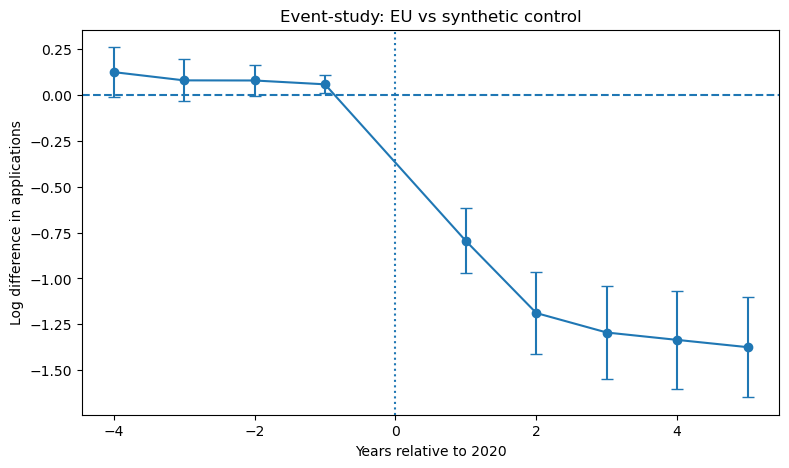

In [6]:
plt.figure(figsize=(9, 5))
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle=":")
plt.errorbar(
    plot_df["event_time"],
    plot_df["estimate"],
    yerr=1.96 * plot_df["std_error"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Years relative to 2020")
plt.ylabel("Log difference in applications")
plt.title("Event-study: EU vs synthetic control")
plt.show()


In [7]:
# ----------------------------
# Wald test: pre-trends
# H0: coefficients on event_-4, event_-3, event_-2, event_-1 = 0
# ----------------------------
pre_terms = ["event_-4", "event_-3", "event_-2", "event_-1"]
pre_terms = [t for t in pre_terms if t in res_event.params.index]

b = res_event.params[pre_terms].values
V = res_event.cov.loc[pre_terms, pre_terms].values

W = b.T @ np.linalg.inv(V) @ b
df_wald = len(pre_terms)
p_value = 1 - stats.chi2.cdf(W, df_wald)

print("Wald statistic:", W)
print("df:", df_wald)
print("p-value:", p_value)


Wald statistic: 6.717711426796582
df: 4
p-value: 0.15157933290685588


In [9]:
# ----------------------------
# Placebo event study: fake Brexit in 2018
# ref = -1
# ----------------------------
df["event_time_pl2018"] = df["Year"] - 2018

event_times_pl = sorted(df["event_time_pl2018"].unique())
placebo_cols = {}

for et in event_times_pl:
    if et == -1:
        continue
    colname = f"pl2018_{et}"
    placebo_cols[colname] = ((df["event_time_pl2018"] == et) & (df["EU"] == 1)).astype(int)

X_pl2018 = pd.DataFrame(placebo_cols, index=df.index)

df_panel = df.set_index(["Domicile_named_country", "Year"]).sort_index()
X_pl2018.index = df_panel.index
y_pl2018 = np.log(df_panel["Applicants"])

m_placebo_2018 = PanelOLS(
    dependent=y_pl2018,
    exog=X_pl2018,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_placebo_2018 = m_placebo_2018.fit(cov_type="clustered", cluster_entity=True)
print(res_placebo_2018.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             Applicants   R-squared:                        0.6479
Estimator:                   PanelOLS   R-squared (Between):             -0.0961
No. Observations:                 520   R-squared (Within):               0.6914
Date:                Sat, Mar 14 2026   R-squared (Overall):             -0.0924
Time:                        23:29:21   Log-likelihood                    4.8509
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      92.014
Entities:                          52   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                   F(9,450)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             13.680
                            

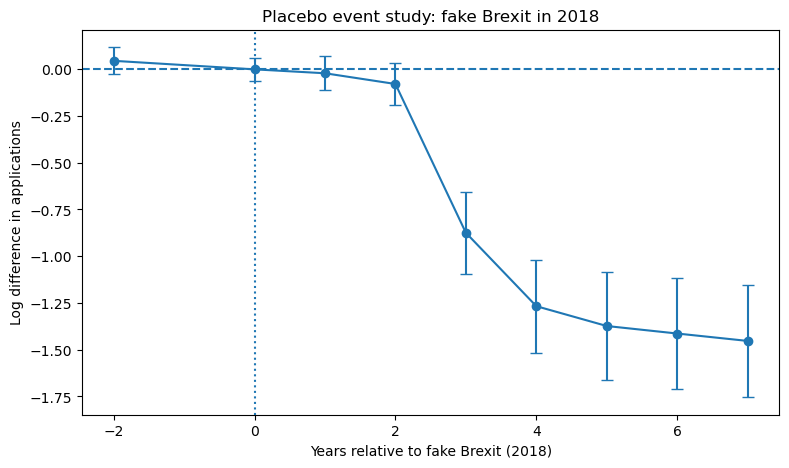

In [10]:
coef = res_placebo_2018.params
se = res_placebo_2018.std_errors

plot_df_pl2018 = pd.DataFrame({
    "term": coef.index,
    "estimate": coef.values,
    "std_error": se.values
})

plot_df_pl2018["event_time"] = plot_df_pl2018["term"].str.extract(r'pl2018_(-?\d+)').astype(int)
plot_df_pl2018["conf_low"] = plot_df_pl2018["estimate"] - 1.96 * plot_df_pl2018["std_error"]
plot_df_pl2018["conf_high"] = plot_df_pl2018["estimate"] + 1.96 * plot_df_pl2018["std_error"]
plot_df_pl2018 = plot_df_pl2018.sort_values("event_time")

plt.figure(figsize=(9, 5))
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle=":")
plt.errorbar(
    plot_df_pl2018["event_time"],
    plot_df_pl2018["estimate"],
    yerr=1.96 * plot_df_pl2018["std_error"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Years relative to fake Brexit (2018)")
plt.ylabel("Log difference in applications")
plt.title("Placebo event study: fake Brexit in 2018")
plt.show()


In [11]:
# ----------------------------
# Leads-only sample
# ----------------------------
df_pre = df[df["Year"] < 2021].copy()
df_pre["event_time"] = df_pre["Year"] - 2020

event_times_pre = sorted(df_pre["event_time"].unique())
lead_cols = {}

for et in event_times_pre:
    if et == 0:
        continue
    colname = f"lead_{et}"
    lead_cols[colname] = ((df_pre["event_time"] == et) & (df_pre["EU"] == 1)).astype(int)

X_leads = pd.DataFrame(lead_cols, index=df_pre.index)

df_pre_panel = df_pre.set_index(["Domicile_named_country", "Year"]).sort_index()
X_leads.index = df_pre_panel.index
y_leads = np.log(df_pre_panel["Applicants"])

m_leads_only = PanelOLS(
    dependent=y_leads,
    exog=X_leads,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_leads_only = m_leads_only.fit(cov_type="clustered", cluster_entity=True)
print(res_leads_only.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             Applicants   R-squared:                        0.0400
Estimator:                   PanelOLS   R-squared (Between):              0.0097
No. Observations:                 260   R-squared (Within):              -0.0551
Date:                Sat, Mar 14 2026   R-squared (Overall):              0.0097
Time:                        23:30:02   Log-likelihood                    233.78
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.0848
Entities:                          52   P-value                           0.0842
Avg Obs:                       5.0000   Distribution:                   F(4,200)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             1.4928
                            

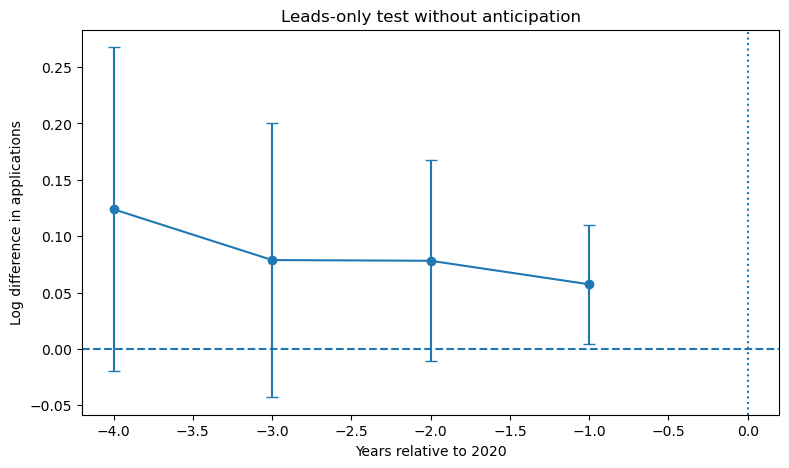

In [12]:
coef = res_leads_only.params
se = res_leads_only.std_errors

plot_df_leads = pd.DataFrame({
    "term": coef.index,
    "estimate": coef.values,
    "std_error": se.values
})

plot_df_leads["event_time"] = plot_df_leads["term"].str.extract(r'lead_(-?\d+)').astype(int)
plot_df_leads["conf_low"] = plot_df_leads["estimate"] - 1.96 * plot_df_leads["std_error"]
plot_df_leads["conf_high"] = plot_df_leads["estimate"] + 1.96 * plot_df_leads["std_error"]
plot_df_leads = plot_df_leads.sort_values("event_time")

plt.figure(figsize=(9, 5))
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle=":")
plt.errorbar(
    plot_df_leads["event_time"],
    plot_df_leads["estimate"],
    yerr=1.96 * plot_df_leads["std_error"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Years relative to 2020")
plt.ylabel("Log difference in applications")
plt.title("Leads-only test without anticipation")
plt.show()


In [13]:
lead_terms = ["lead_-4", "lead_-3", "lead_-2", "lead_-1"]
lead_terms = [t for t in lead_terms if t in res_leads_only.params.index]

b = res_leads_only.params[lead_terms].values
V = res_leads_only.cov.loc[lead_terms, lead_terms].values

W = b.T @ np.linalg.inv(V) @ b
df_wald = len(lead_terms)
p_value = 1 - stats.chi2.cdf(W, df_wald)

print("Leads-only Wald statistic:", W)
print("df:", df_wald)
print("p-value:", p_value)


Leads-only Wald statistic: 5.97129904604153
df: 4
p-value: 0.20130195548825525


In [14]:
# ----------------------------
# Randomized placebo treatment
# ----------------------------
np.random.seed(123)

countries = df["Domicile_named_country"].unique()
fake_EU = np.random.choice(countries, size=len(eu_real), replace=False)

df["EU_placebo"] = df["Domicile_named_country"].isin(fake_EU).astype(int)
df["event_time"] = df["Year"] - 2020

event_times_rand = sorted(df["event_time"].unique())
rand_cols = {}

for et in event_times_rand:
    if et == 0:
        continue
    colname = f"rand_{et}"
    rand_cols[colname] = ((df["event_time"] == et) & (df["EU_placebo"] == 1)).astype(int)

X_rand = pd.DataFrame(rand_cols, index=df.index)

df_panel = df.set_index(["Domicile_named_country", "Year"]).sort_index()
X_rand.index = df_panel.index
y_rand = np.log(df_panel["Applicants"])

m_placebo_random = PanelOLS(
    dependent=y_rand,
    exog=X_rand,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_placebo_random = m_placebo_random.fit(cov_type="clustered", cluster_entity=True)
print(res_placebo_random.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             Applicants   R-squared:                        0.0064
Estimator:                   PanelOLS   R-squared (Between):             -0.0039
No. Observations:                 520   R-squared (Within):               0.0657
Date:                Sat, Mar 14 2026   R-squared (Overall):             -0.0036
Time:                        23:31:07   Log-likelihood                   -264.90
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.3213
Entities:                          52   P-value                           0.9679
Avg Obs:                      10.0000   Distribution:                   F(9,450)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):             0.4208
                            

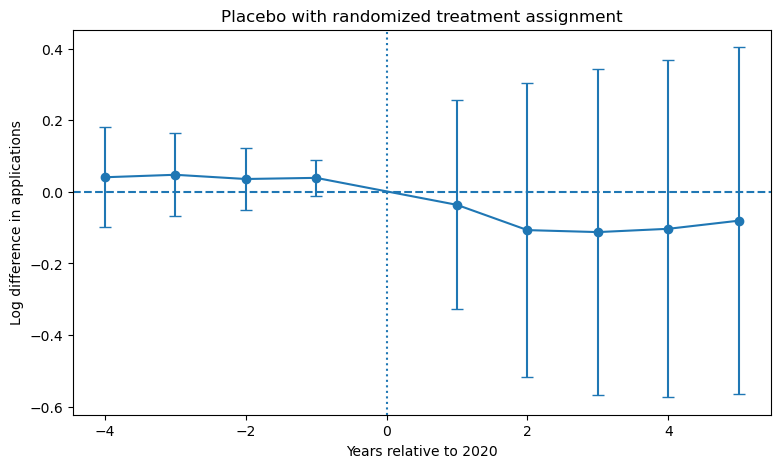

In [15]:
coef = res_placebo_random.params
se = res_placebo_random.std_errors

plot_df_rand = pd.DataFrame({
    "term": coef.index,
    "estimate": coef.values,
    "std_error": se.values
})

plot_df_rand["event_time"] = plot_df_rand["term"].str.extract(r'rand_(-?\d+)').astype(int)
plot_df_rand["conf_low"] = plot_df_rand["estimate"] - 1.96 * plot_df_rand["std_error"]
plot_df_rand["conf_high"] = plot_df_rand["estimate"] + 1.96 * plot_df_rand["std_error"]
plot_df_rand = plot_df_rand.sort_values("event_time")

plt.figure(figsize=(9, 5))
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle=":")
plt.errorbar(
    plot_df_rand["event_time"],
    plot_df_rand["estimate"],
    yerr=1.96 * plot_df_rand["std_error"],
    fmt="o-",
    capsize=4
)
plt.xlabel("Years relative to 2020")
plt.ylabel("Log difference in applications")
plt.title("Placebo with randomized treatment assignment")
plt.show()


In [16]:
# ----------------------------
# Saturated event study by country
# ----------------------------
df = pdata_UCAS.reset_index().copy()
df["Domicile_named_country"] = df["Domicile_named_country"].astype(str)
df["Year"] = df["Year"].astype(int)

df["event_time"] = df["Year"] - 2020
df["Treated"] = df["Domicile_named_country"].isin(eu_real)

df["treated_factor"] = np.where(
    df["Treated"],
    df["Domicile_named_country"],
    "CONTROL"
)

print(df["Domicile_named_country"].head())
print(df["treated_factor"].head())
print(sorted(df["treated_factor"].unique()))


0    Albania
1    Albania
2    Albania
3    Albania
4    Albania
Name: Domicile_named_country, dtype: object
0    CONTROL
1    CONTROL
2    CONTROL
3    CONTROL
4    CONTROL
Name: treated_factor, dtype: object
['Austria', 'Belgium', 'Bulgaria', 'CONTROL', 'Croatia', 'Cyprus (European Union)', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']


In [17]:
sat_cols = {}

treated_countries = sorted([c for c in df["treated_factor"].unique() if c != "CONTROL"])
event_times = sorted(df["event_time"].unique())

for country in treated_countries:
    for et in event_times:
        if et == 0:
            continue
        colname = f"{country}__{et}"
        sat_cols[colname] = ((df["treated_factor"] == country) & (df["event_time"] == et)).astype(int)

X_sat = pd.DataFrame(sat_cols, index=df.index)

df_sat_panel = df.set_index(["Domicile_named_country", "Year"]).sort_index()
X_sat.index = df_sat_panel.index
y_sat = np.log(df_sat_panel["Applicants"])


In [18]:
m_sat_event = PanelOLS(
    dependent=y_sat,
    exog=X_sat,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_sat_event = m_sat_event.fit(cov_type="clustered", cluster_entity=True)
print(res_sat_event.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:             Applicants   R-squared:                        0.8824
Estimator:                   PanelOLS   R-squared (Between):             -0.0839
No. Observations:                 520   R-squared (Within):               0.8677
Date:                Sat, Mar 14 2026   R-squared (Overall):             -0.0795
Time:                        23:32:02   Log-likelihood                    289.91
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.2133
Entities:                          52   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                 F(234,225)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):         -1.361e+15
                            

In [19]:
plot_sat_df = pd.DataFrame({
    "term": res_sat_event.params.index,
    "estimate": res_sat_event.params.values,
    "std_error": res_sat_event.std_errors.values
})

plot_sat_df[["country", "event_time"]] = plot_sat_df["term"].str.extract(r"^(.*)__(-?\d+)$")
plot_sat_df["event_time"] = plot_sat_df["event_time"].astype(int)
plot_sat_df["conf_low"] = plot_sat_df["estimate"] - 1.96 * plot_sat_df["std_error"]
plot_sat_df["conf_high"] = plot_sat_df["estimate"] + 1.96 * plot_sat_df["std_error"]

plot_sat_df = plot_sat_df.sort_values(["country", "event_time"])
print(plot_sat_df.head())


          term  estimate  std_error  country  event_time  conf_low  conf_high
0  Austria__-4  0.268438   0.079500  Austria          -4  0.112618   0.424258
1  Austria__-3  0.167863   0.063773  Austria          -3  0.042868   0.292858
2  Austria__-2  0.177544   0.047288  Austria          -2  0.084859   0.270229
3  Austria__-1  0.162355   0.029070  Austria          -1  0.105378   0.219331
4   Austria__1 -0.358804   0.040461  Austria           1 -0.438107  -0.279500


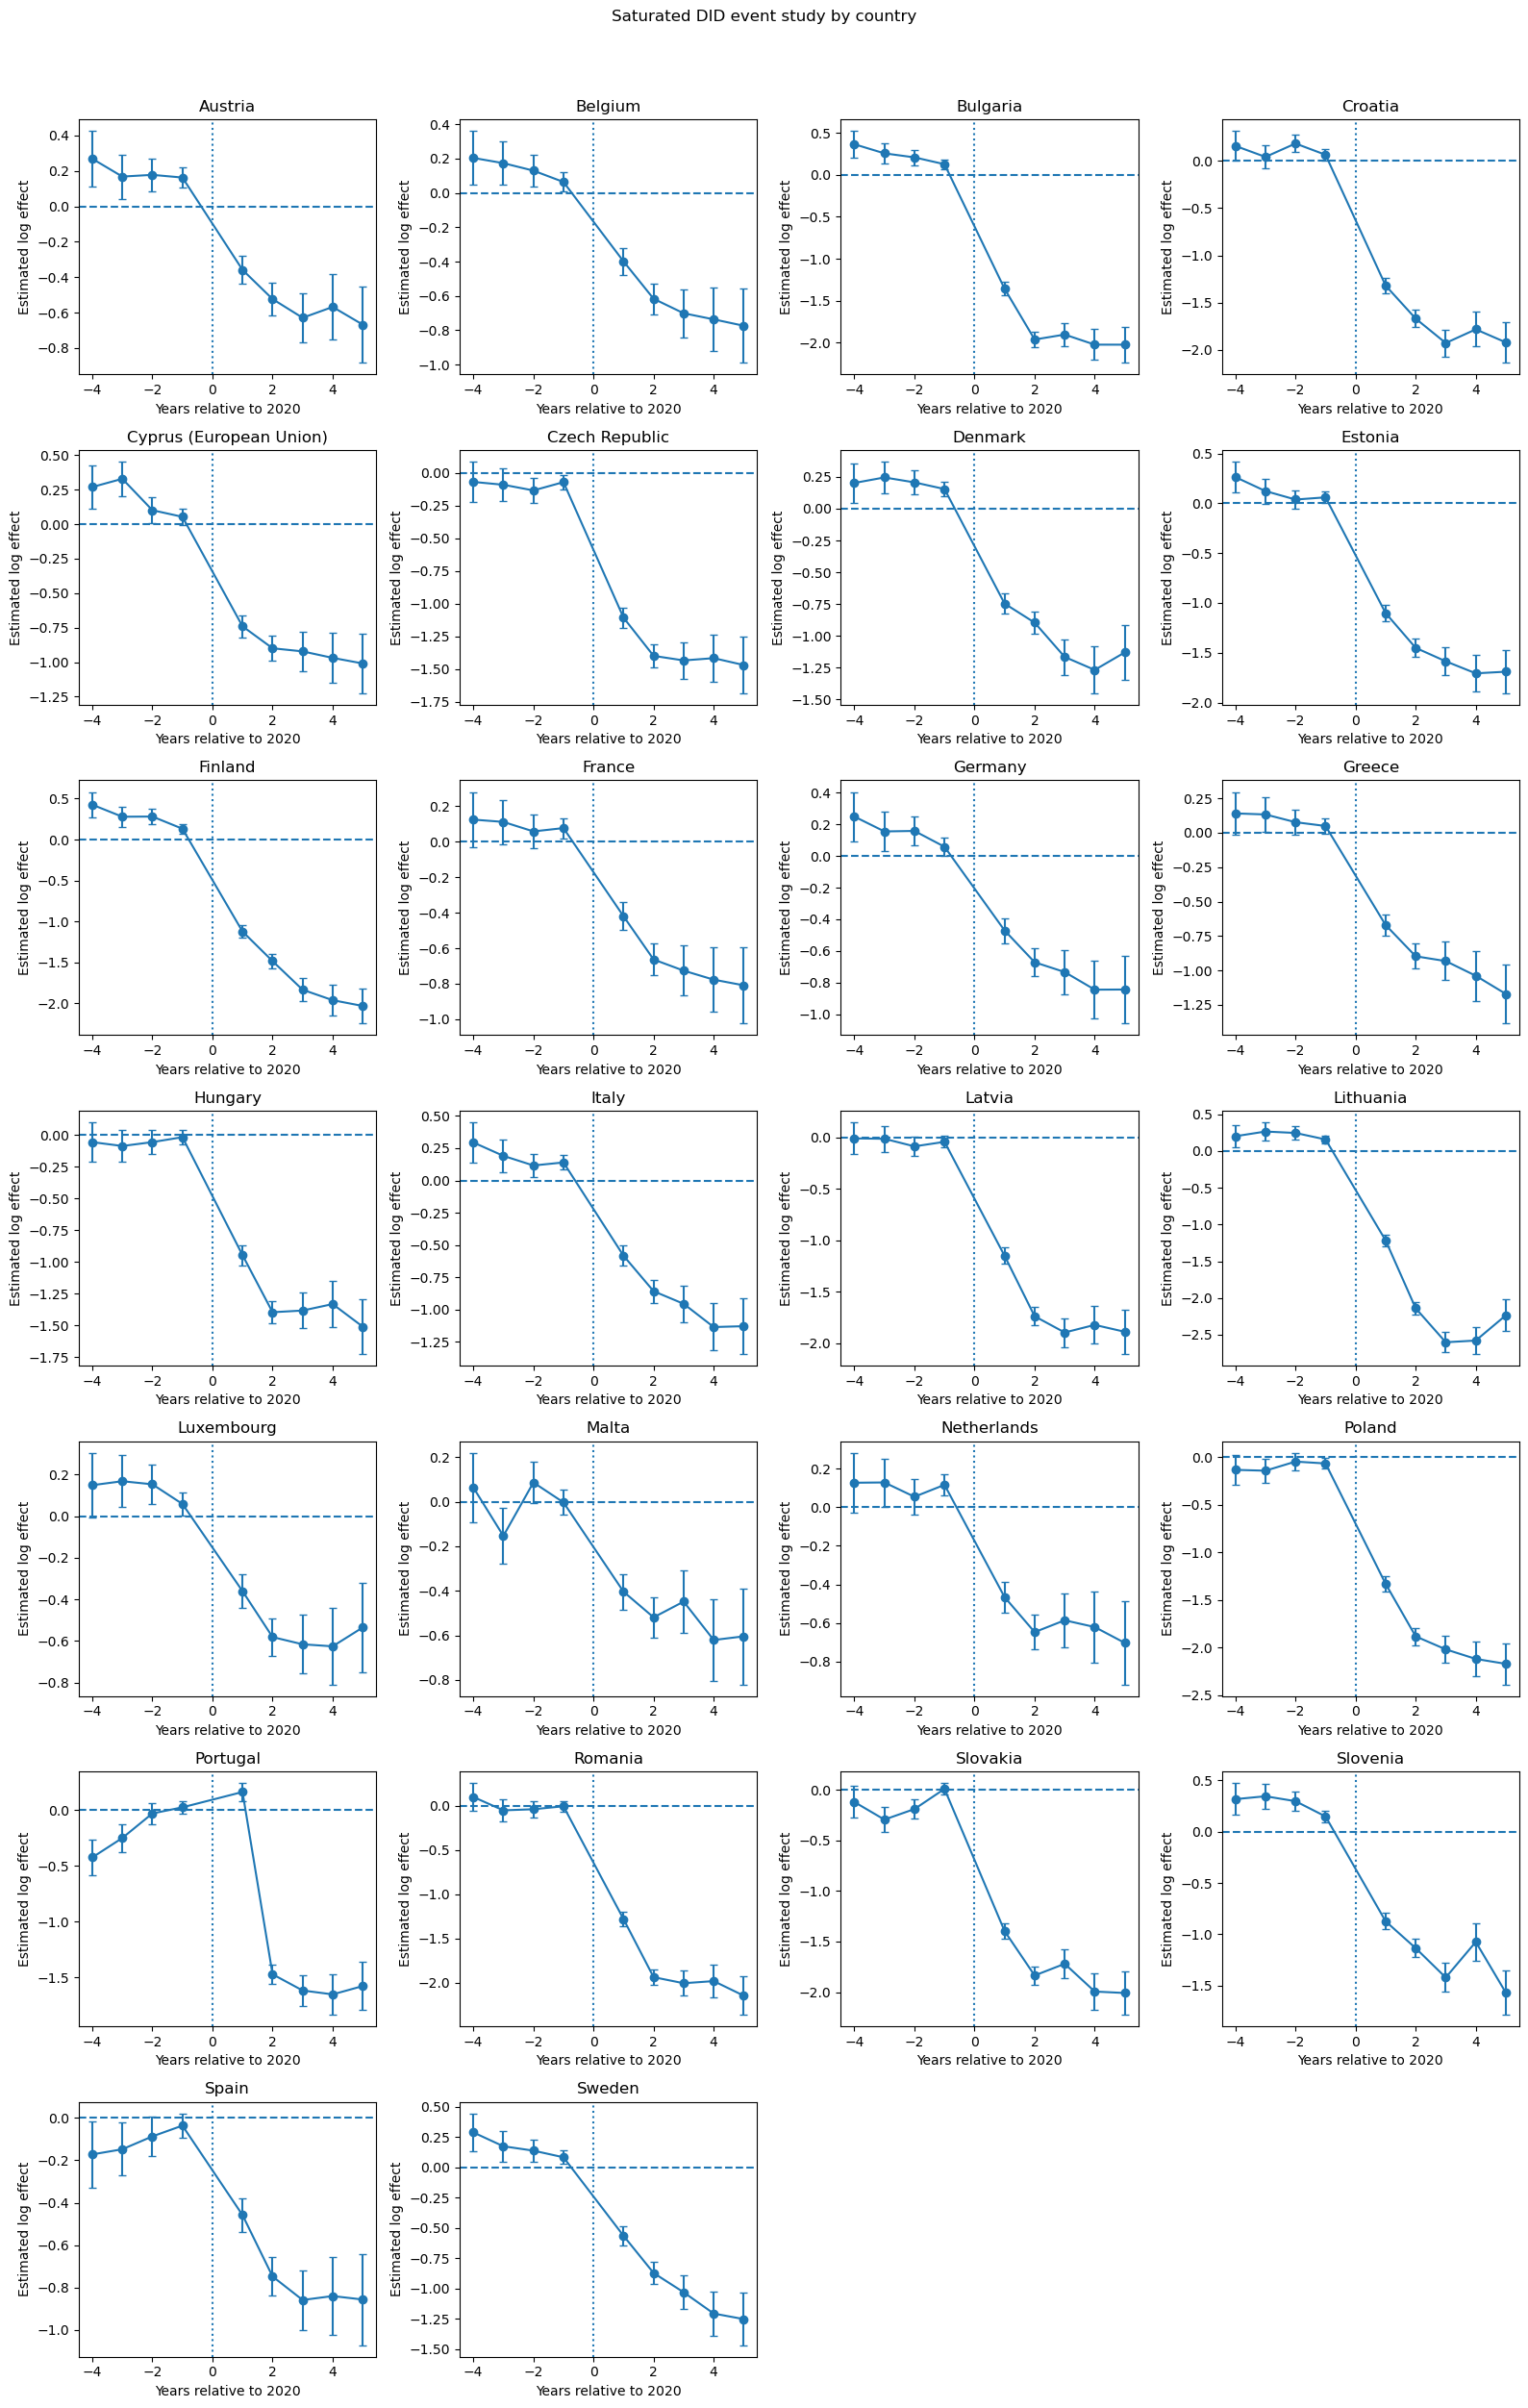

In [20]:
countries = plot_sat_df["country"].unique()
n = len(countries)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for ax, country in zip(axes, countries):
    sub = plot_sat_df[plot_sat_df["country"] == country]
    ax.axhline(0, linestyle="--")
    ax.axvline(0, linestyle=":")
    ax.errorbar(
        sub["event_time"],
        sub["estimate"],
        yerr=1.96 * sub["std_error"],
        fmt="o-",
        capsize=3
    )
    ax.set_title(country)
    ax.set_xlabel("Years relative to 2020")
    ax.set_ylabel("Estimated log effect")

# Hide unused axes
for ax in axes[len(countries):]:
    ax.set_visible(False)

fig.suptitle("Saturated DID event study by country", y=1.02)
plt.tight_layout()
plt.show()


                   country  log_change  conf_low_log  conf_high_log  \
0                  Austria   -0.704804     -0.866481      -0.543127   
1                  Belgium   -0.758927     -0.951224      -0.566630   
2                 Bulgaria   -2.043416     -2.359198      -1.727633   
3                  Croatia   -1.811014     -2.059726      -1.562303   
4  Cyprus (European Union)   -1.058432     -1.255379      -0.861486   

   pct_change_Q  eta_arc_did   eta_log  
0     -0.505795    -0.361282 -0.805059  
1     -0.531831    -0.379880 -0.866880  
2     -0.870415    -0.621725 -2.334082  
3     -0.836512    -0.597508 -2.068622  
4     -0.653001    -0.466429 -1.208989  
                   country  app_pre  app_post  eta_mechanical
0                  Austria    550.0     405.0       -0.188312
1                  Belgium   1025.0     725.0       -0.209059
2                 Bulgaria   1935.0     525.0       -0.520487
3                  Croatia    355.0     100.0       -0.513078
4  Cyprus (Europe

C:\Users\Stoycho.rusinov\AppData\Local\Temp\ipykernel_17000\176362530.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


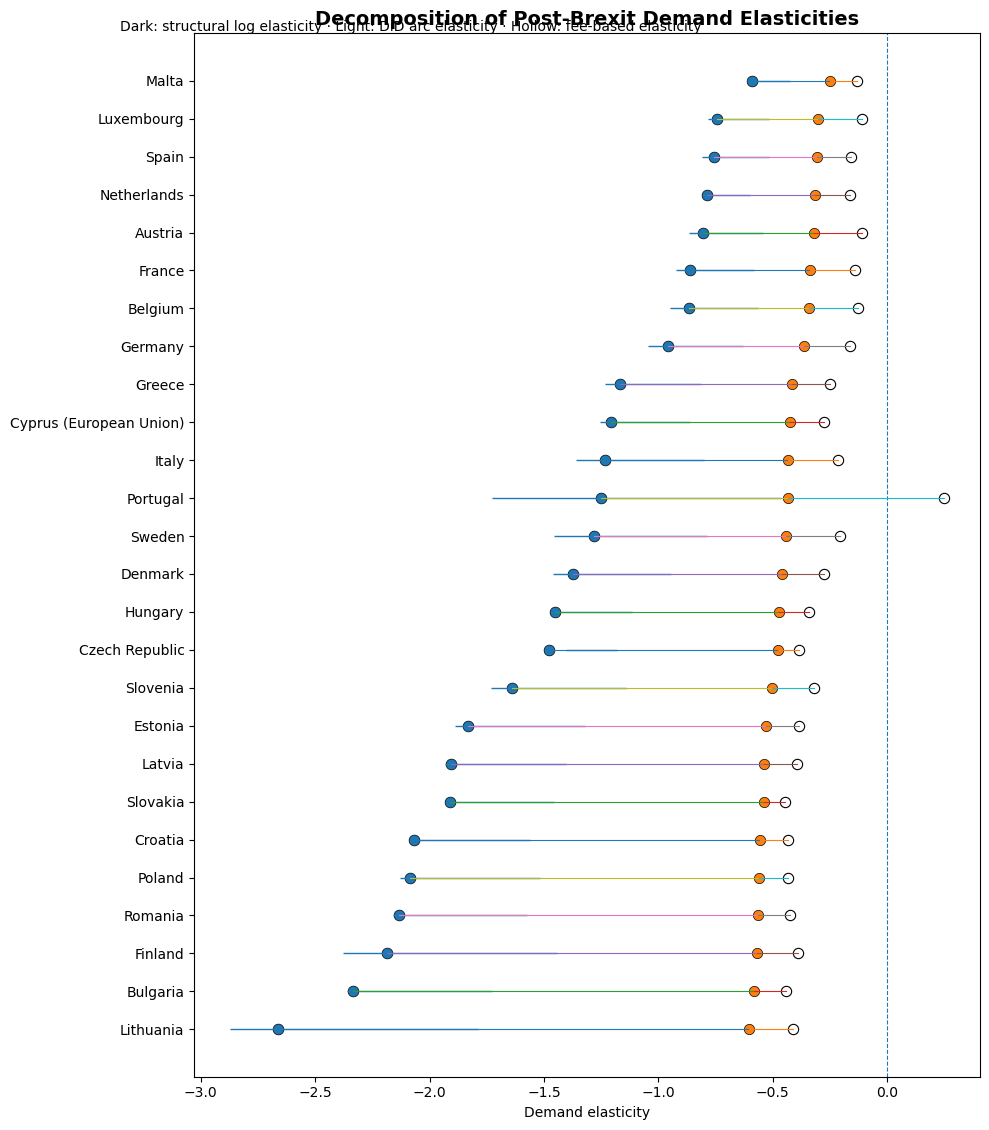

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# 1. Brexit tuition shock
# -----------------------------------

fee_pre = 9250
fee_post = 22200

x = np.log(fee_post / fee_pre)                      # log price change
pct_fee_change = (fee_post - fee_pre) / fee_pre    # ≈ 1.40

# -----------------------------------
# 2. Elasticities from DiD regression
# -----------------------------------
# res_sat_DK is the fitted PanelOLS result
# from the saturated DID with country + year FE

did_df = pd.DataFrame({
    "term": res_sat_DK.params.index,
    "estimate": res_sat_DK.params.values,
    "std_error": res_sat_DK.std_errors.values
})

# Keep only treated-country coefficients
did_df = did_df[did_df["term"].str.startswith("tf_")].copy()

# Country names
did_df["country"] = did_df["term"].str.replace(r"^tf_", "", regex=True)

# 95% CI
did_df["conf.low"] = did_df["estimate"] - 1.96 * did_df["std_error"]
did_df["conf.high"] = did_df["estimate"] + 1.96 * did_df["std_error"]

# Elasticity objects
did_df["beta"] = did_df["estimate"]                 # Δ log Q
did_df["log_change"] = did_df["beta"]
did_df["conf_low_log"] = did_df["conf.low"]
did_df["conf_high_log"] = did_df["conf.high"]

did_df["pct_change_Q"] = np.exp(did_df["beta"]) - 1
did_df["eta_arc_did"] = (np.exp(did_df["beta"]) - 1) / pct_fee_change
did_df["eta_log"] = did_df["beta"] / x

did_df = did_df[[
    "country", "log_change", "conf_low_log", "conf_high_log",
    "pct_change_Q", "eta_arc_did", "eta_log"
]].copy()

print(did_df.head())

# -----------------------------------
# 3. Mechanical fee-based elasticity
# -----------------------------------

fee_df = (
    df[df["Domicile_named_country"].isin(eu_real)]
    .groupby("Domicile_named_country", as_index=False)
    .apply(lambda g: pd.Series({
        "app_pre": g.loc[g["Year"] == 2020, "Applicants"].mean(),
        "app_post": g.loc[g["Year"] == 2021, "Applicants"].mean()
    }))
    .reset_index(drop=True)
)

fee_df["eta_mechanical"] = (
    ((fee_df["app_post"] - fee_df["app_pre"]) / fee_df["app_pre"]) / pct_fee_change
)

fee_df = fee_df.rename(columns={"Domicile_named_country": "country"})

print(fee_df.head())

# -----------------------------------
# 4. Merge datasets
# -----------------------------------

plot_df = (
    did_df.merge(fee_df[["country", "eta_mechanical"]], on="country", how="left")
    .sort_values("eta_log")
    .reset_index(drop=True)
)

# small horizontal offsets so points don’t overlap
plot_df["eta_arc_shift"] = plot_df["eta_arc_did"] + 0.04
plot_df["eta_mech_shift"] = plot_df["eta_mechanical"] + 0.08

# y positions for plotting
plot_df["ypos"] = np.arange(len(plot_df))

print(plot_df.head())

# -----------------------------------
# 5. Plot
# -----------------------------------

fig, ax = plt.subplots(figsize=(10, 12))

# zero line
ax.axvline(0, linestyle="--", linewidth=0.8)

# confidence intervals for structural elasticity
# IMPORTANT:
# In your R code, the CI plotted is still on the beta/log-change scale,
# not divided by x. To reproduce that exactly, use conf_low_log/conf_high_log.
# If you want CI for eta_log instead, divide those bounds by x.
ax.hlines(
    y=plot_df["ypos"],
    xmin=plot_df["conf_low_log"],
    xmax=plot_df["conf_high_log"],
    linewidth=1.0
)

# connectors
for _, row in plot_df.iterrows():
    ax.plot(
        [row["eta_log"], row["eta_arc_shift"]],
        [row["ypos"], row["ypos"]],
        linewidth=0.8
    )
    ax.plot(
        [row["eta_arc_shift"], row["eta_mech_shift"]],
        [row["ypos"], row["ypos"]],
        linewidth=0.8
    )

# (A) Structural elasticity
ax.scatter(
    plot_df["eta_log"],
    plot_df["ypos"],
    s=60,
    edgecolors="black",
    linewidths=0.5
)

# (B) DiD arc elasticity
ax.scatter(
    plot_df["eta_arc_shift"],
    plot_df["ypos"],
    s=55,
    edgecolors="black",
    linewidths=0.5
)

# (C) Mechanical fee elasticity
ax.scatter(
    plot_df["eta_mech_shift"],
    plot_df["ypos"],
    s=55,
    facecolors="white",
    edgecolors="black",
    linewidths=0.8
)

# labels and layout
ax.set_yticks(plot_df["ypos"])
ax.set_yticklabels(plot_df["country"])
ax.set_xlabel("Demand elasticity")
ax.set_ylabel("")
ax.set_title("Decomposition of Post-Brexit Demand Elasticities", fontsize=14, fontweight="bold")

# subtitle substitute
fig.text(
    0.125, 0.92,
    "Dark: structural log elasticity · Light: DiD arc elasticity · Hollow: fee-based elasticity",
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


                          PanelOLS Estimation Summary                           
Dep. Variable:             Applicants   R-squared:                        0.8390
Estimator:                   PanelOLS   R-squared (Between):             -0.0939
No. Observations:                 520   R-squared (Within):               0.8335
Date:                Sat, Mar 14 2026   R-squared (Overall):             -0.0896
Time:                        23:48:48   Log-likelihood                    208.22
Cov. Estimator:        Driscoll-Kraay                                           
                                        F-statistic:                      40.774
Entities:                          52   P-value                           0.0000
Avg Obs:                      10.0000   Distribution:                  F(52,407)
Min Obs:                      10.0000                                           
Max Obs:                      10.0000   F-statistic (robust):         -2.324e+16
                            

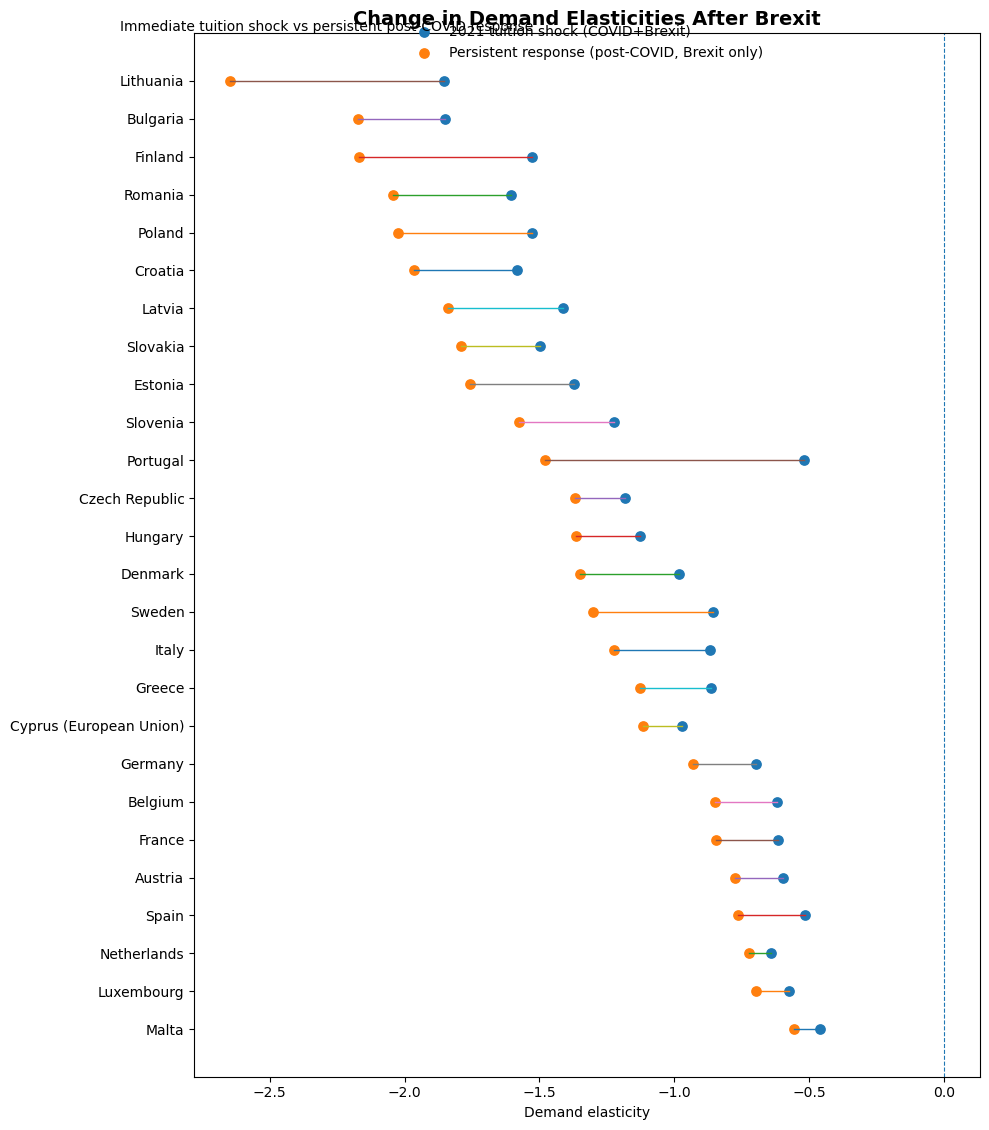

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS

# =========================================================
# S-DID design DE with COVID and Post-COVID coefficients
# =========================================================

# -----------------------------------
# 1. Prepare variables
# -----------------------------------
df2 = df.copy()

df2["Domicile_named_country"] = df2["Domicile_named_country"].astype(str)
df2["Year"] = df2["Year"].astype(int)

df2["Post_COVID"] = (df2["Year"] >= 2023).astype(int)
df2["Post"] = df2["Year"].isin([2021, 2022]).astype(int)
df2["Treated"] = df2["Domicile_named_country"].isin(eu_real).astype(int)

df2["treated_factor"] = np.where(
    df2["Treated"] == 1,
    df2["Domicile_named_country"],
    "CONTROL"
)

# -----------------------------------
# 2. Build interaction terms
# -----------------------------------
treated_dummies = pd.get_dummies(df2["treated_factor"], prefix="tf", dtype=float)

if "tf_CONTROL" in treated_dummies.columns:
    treated_only = treated_dummies.drop(columns=["tf_CONTROL"]).copy()
else:
    treated_only = treated_dummies.copy()

# 2021-2022 interaction block
X_post = treated_only.mul(df2["Post"].to_numpy(), axis=0)
X_post.columns = [f"{col}_Post" for col in X_post.columns]

# 2023+ interaction block
X_post_covid = treated_only.mul(df2["Post_COVID"].to_numpy(), axis=0)
X_post_covid.columns = [f"{col}_Post_COVID" for col in X_post_covid.columns]

# Combine the two blocks
X_two_period = pd.concat([X_post, X_post_covid], axis=1)

# -----------------------------------
# 3. Panel setup
# -----------------------------------
df2_panel = df2.set_index(["Domicile_named_country", "Year"]).sort_index()
X_two_period.index = df2_panel.index
y_two_period = np.log(df2_panel["Applicants"])

# -----------------------------------
# 4. Estimate model
# -----------------------------------
m_sat_DK_2 = PanelOLS(
    dependent=y_two_period,
    exog=X_two_period,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

res_sat_DK_2 = m_sat_DK_2.fit(cov_type="driscoll-kraay")
print(res_sat_DK_2.summary)

# -----------------------------------
# 5. Extract coefficients safely
# -----------------------------------
coef_long = pd.DataFrame({
    "term": res_sat_DK_2.params.index.astype(str),
    "estimate": res_sat_DK_2.params.values,
    "std_error": res_sat_DK_2.std_errors.values
})

# Keep only treated-factor coefficients
coef_long = coef_long[coef_long["term"].str.startswith("tf_")].copy()

# Create period column WITHOUT np.where
coef_long["period"] = pd.Series([None] * len(coef_long), index=coef_long.index, dtype="object")

coef_long.loc[
    coef_long["term"].str.endswith("_Post_COVID"),
    "period"
] = "Post-COVID"

coef_long.loc[
    coef_long["term"].str.endswith("_Post"),
    "period"
] = "Post-Brexit"

# Extract country name
coef_long["country"] = coef_long["term"].str.replace(r"^tf_", "", regex=True)
coef_long["country"] = coef_long["country"].str.replace(r"_(Post|Post_COVID)$", "", regex=True)

coef_long["elasticity"] = coef_long["estimate"]

# Keep only valid rows
coef_long = coef_long[coef_long["period"].notna()].copy()

print(coef_long.head())

# -----------------------------------
# 6. Wide version for ordering and connecting lines
# -----------------------------------
plot_df2 = (
    coef_long[["country", "period", "elasticity"]]
    .pivot(index="country", columns="period", values="elasticity")
    .reset_index()
)

plot_df2 = plot_df2.sort_values("Post-COVID", ascending=False).reset_index(drop=True)
plot_df2["ypos"] = np.arange(len(plot_df2))

print(plot_df2.head())

# -----------------------------------
# 7. Long version for plotting points and legend
# -----------------------------------
plot_df_long = plot_df2.melt(
    id_vars=["country", "ypos"],
    value_vars=["Post-Brexit", "Post-COVID"],
    var_name="period",
    value_name="elasticity"
)

label_map = {
    "Post-Brexit": "2021 tuition shock (COVID+Brexit)",
    "Post-COVID": "Persistent response (post-COVID, Brexit only)"
}

plot_df_long["period_label"] = plot_df_long["period"].map(label_map)

print(plot_df_long.head())

# -----------------------------------
# 8. Plot
# -----------------------------------
fig, ax = plt.subplots(figsize=(10, 12))

# Connecting segments
for _, row in plot_df2.iterrows():
    ax.plot(
        [row["Post-Brexit"], row["Post-COVID"]],
        [row["ypos"], row["ypos"]],
        linewidth=1.0
    )

# Point layers
for label, sub in plot_df_long.groupby("period_label"):
    ax.scatter(
        sub["elasticity"],
        sub["ypos"],
        s=45,
        label=label
    )

# Zero line
ax.axvline(0, linestyle="--", linewidth=0.8)

# Axes and labels
ax.set_yticks(plot_df2["ypos"])
ax.set_yticklabels(plot_df2["country"])
ax.set_xlabel("Demand elasticity")
ax.set_ylabel("")
ax.set_title("Change in Demand Elasticities After Brexit", fontsize=14, fontweight="bold")

# Subtitle
fig.text(
    0.125, 0.92,
    "Immediate tuition shock vs persistent post-COVID response",
    fontsize=10
)

# Legend
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()